In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)

# Define the transformations for the images
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('csebuetnlp/banglabert')

# Custom Dataset class
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = 1 if row['Label'] == 'fake' else 0
        image_id = row['Image id']

        image_path = os.path.join(self.images_folder, image_id)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"{image_path} not found")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

        return {
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
images_folder = '/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Without text/'
train_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms)
valid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Index(['Image id', 'Caption', 'Label'], dtype='object')


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [2]:
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

2700
900
900


In [3]:
import torch.nn as nn
from transformers import BertModel
import torchvision.models as models

class MultimodalModel(nn.Module):
    def __init__(self, text_model_name='csebuetnlp/banglabert', num_labels=2):
        super(MultimodalModel, self).__init__()
        self.text_model = BertModel.from_pretrained(text_model_name)
        self.image_model = models.resnet50(pretrained=True)
        self.image_model.fc = nn.Linear(self.image_model.fc.in_features, 768)  # Adjust to match BERT output size

        self.classifier = nn.Linear(768 * 2, num_labels)

    def forward(self, input_ids, attention_mask, image):
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_embeds = text_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding

        image_embeds = self.image_model(image)

        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)

        return logits

model = MultimodalModel(num_labels=len(df['Label'].unique()))


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

You are using a model of type `electra` to instantiate a model of type `bert`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

BertModel LOAD REPORT from: csebuetnlp/banglabert
Key                                                              | Status     | 
-----------------------------------------------------------------+------------+-
electra.encoder.layer.{0...11}.attention.self.value.bias         | UNEXPECTED | 
electra.encoder.layer.{0...11}.attention.self.key.weight         | UNEXPECTED | 
electra.encoder.layer.{0...11}.attention.output.dense.bias       | UNEXPECTED | 
electra.encoder.layer.{0...11}.output.LayerNorm.weight           | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias                  | UNEXPECTED | 
electra.encoder.layer.{0...11}.attention.self.key.bias           | UNEXPECTED | 
electra.encoder.layer.{0...11}.attention.output.dense.weight     | UNEXPECTED | 
electra.encoder.layer.{0...11}.output.dense.bias                 | UNEXPECTED | 
electra.encoder.layer.{0...11}.attention.output.LayerNorm.bias   | UNEXPECTED | 
electra.encoder.layer.{0...11}.intermediate.dense.bias     

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  9%|▉         | 8.88M/97.8M [00:00<00:01, 92.8MB/s]
 34%|███▎      | 33.0M/97.8M [00:00<00:00, 187MB/s] 
 59%|█████▊    | 57.2M/97.8M [00:00<00:00, 217MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


In [4]:
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
criterion = CrossEntropyLoss()

def train_model(model, train_loader, valid_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss}")

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in valid_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask, images)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(valid_loader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_val_loss}")

train_model(model, train_loader, valid_loader, epochs=5)


100%|██████████| 85/85 [03:05<00:00,  2.18s/it]


Epoch 1, Train Loss: 0.22701370069647536
Epoch 1, Validation Loss: 0.059695322516149486


100%|██████████| 85/85 [02:50<00:00,  2.00s/it]


Epoch 2, Train Loss: 0.018670830453800805
Epoch 2, Validation Loss: 0.021913384171684498


100%|██████████| 85/85 [02:50<00:00,  2.00s/it]


Epoch 3, Train Loss: 0.008717391946736505
Epoch 3, Validation Loss: 0.018895949895397342


100%|██████████| 85/85 [02:50<00:00,  2.01s/it]


Epoch 4, Train Loss: 0.0030196737388477604
Epoch 4, Validation Loss: 0.01987688570355611


100%|██████████| 85/85 [02:49<00:00,  1.99s/it]


Epoch 5, Train Loss: 0.002246442636447575
Epoch 5, Validation Loss: 0.018159968877845475


In [5]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['fake' if label == 1 else 'real' for label in all_labels]
    all_preds = ['fake' if pred == 1 else 'real' for pred in all_preds]
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds)

    return accuracy, precision, recall, f1, report, all_labels, all_preds


In [7]:
def plot_confusion_matrix(all_labels, all_preds):
    labels = ['fake', 'real']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


In [8]:
test_accuracy, test_precision, test_recall, test_f1, test_report, all_labels, all_preds = evaluate_model(model, test_loader)

print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print("Classification Report:\n", test_report)

# Plot the confusion matrix
#plot_confusion_matrix(all_labels, all_preds)

Test Accuracy: 0.9977777777777778
Test Precision: 0.9977873152122079
Test Recall: 0.9977777777777778
Test F1 Score: 0.9977776129856218
Classification Report:
               precision    recall  f1-score   support

        fake       1.00      1.00      1.00       436
        real       1.00      1.00      1.00       464

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



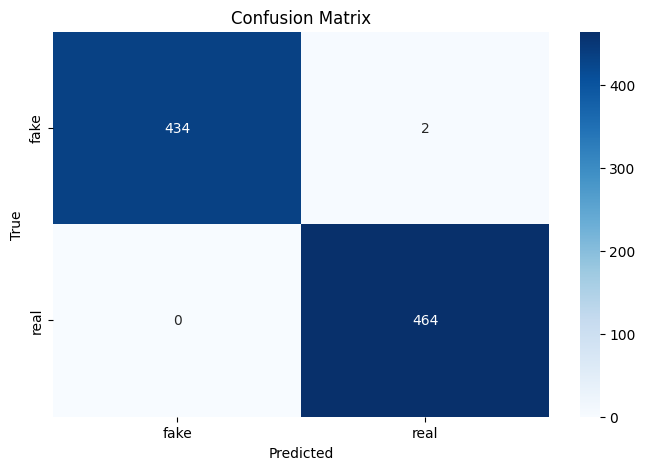

In [9]:
plot_confusion_matrix(all_labels, all_preds)